In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [36]:
import math
import keyring
import itertools
from ast import literal_eval

In [37]:
# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [38]:
# read in the data
# df = pd.read_csv(data_dir + "/data_processed/tbi_merged.csv")
df = pd.read_csv("../../data_processing/tbi_cleaned.csv")
df

C:\Users\fishl\AppData\Local\Temp\ipykernel_11992\2582001599.py:3: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data_processing/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454176,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
454177,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
454178,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
454179,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [39]:
# # read path geopkg data
# feather/aprquet files take an order of magnitude less time to read
car = gpd.read_parquet(data_dir + "/Data_Processed/geodata/car.parquet")
bike = gpd.read_feather(data_dir + "/Data_Processed/geodata/bike_lts.feather")
transit = gpd.read_parquet(data_dir + "/Data_Processed/geodata/transit.parquet")
walk = gpd.read_parquet(data_dir + "/Data_Processed/geodata/walk.parquet")

In [40]:
# preprocess car

In [42]:
# preprocess transit

In [242]:
# transit has no distance
# TODO: project to some non-latlon projection and calcaulte
transit.columns

Index(['trip_id', 'leg_index', 'start_time', 'end_time', 'origin_stop_id',
       'origin_stop_name', 'destination_stop_id', 'destination_stop_name',
       'route_id', 'route_short_name', 'route_long_name', 'route_type',
       'leg_type', 'geometry', 'start_time_dt', 'end_time_dt', 'duration'],
      dtype='object')

In [43]:
# calculate duration from start/eend times
transit["start_time_dt"] = pd.to_datetime(transit["start_time"])
transit["end_time_dt"] = pd.to_datetime(transit["end_time"])

transit["duration"] = (transit["end_time_dt"] - transit["start_time_dt"]).apply(lambda x: x.seconds / 60)

In [44]:
# create a gdf for linked trips
agg_fns = {
    "trip_id": "first",
    "leg_index": "count",
    "start_time": "first",
    "end_time": "last",
    "origin_stop_id": "first", # throw away
    "origin_stop_name": "first",
    "destination_stop_id": "first",
    "destination_stop_name": "first",
    "route_id": "first", 
    "route_short_name": "first",
    "route_long_name": "first",
    "route_type": "first", 
    "leg_type": "first", # end throw away
    "start_time_dt": "first",
    "end_time_dt": "last",
    "duration": "sum"
}

transit_grouped = transit.dissolve(by="trip_id", aggfunc=agg_fns) # merges geometries in addition to aggregating the rest of the columns

In [45]:
# 2013 transit trips lack a corresponding path out of 11271 (18%)
df[(df["mode"] == "Transit") & (~df["trip_id"].isin(transit_grouped["trip_id"]))]

,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
186,190,1,18115411,1811541101,1,3,9.0,"[1811541101009, 1811541101010, 1811541101011, ...",2018-11-28,Wednesday,...,NaN,NaN,NaN,NaN,Yes,Yes,383.703090,383.703090,95.925770,95.925770
190,194,1,18115411,1811541101,1,4,13.0,"[1811541101019, 1811541101020, 1811541101021]",2018-11-29,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,383.703090,383.703090,95.925770,95.925770
193,197,1,18115411,1811541101,1,4,16.0,"[1811541101024, 1811541101025, 1811541101026, ...",2018-11-29,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,383.703090,383.703090,95.925770,95.925770
196,200,1,18115411,1811541101,1,5,19.0,"[1811541101030, 1811541101031, 1811541101032, ...",2018-11-30,Friday,...,NaN,NaN,NaN,NaN,No,Yes,383.703090,383.703090,0.000000,0.000000
199,204,1,18115411,1811541101,1,5,23.0,"[1811541101037, 1811541101038, 1811541101039]",2018-11-30,Friday,...,NaN,NaN,NaN,NaN,No,Yes,383.703090,383.703090,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453596,511553,2,22002480,2200248001,1,6,211507.0,"[2200248001005, 2200248001001, 2200248001002, ...",2021-12-23,Thursday,...,Not selected,Not selected,Other,Not selected,Yes,Missing,452.799851,452.799851,113.199963,113.199963
453597,511555,2,22002480,2200248002,2,6,211509.0,"[2200248002006, 2200248002001, 2200248002002, ...",2021-12-23,Thursday,...,Not selected,Not selected,Not selected,Not selected,Yes,Missing,452.799851,452.799851,113.199963,113.199963
453598,511556,2,22002480,2200248002,2,6,211510.0,"[2200248002007, 2200248002004, 2200248002005, ...",2021-12-23,Thursday,...,Not selected,Not selected,Not selected,Not selected,Yes,Missing,452.799851,452.799851,113.199963,113.199963
453795,511861,2,22002619,2200261901,1,1,211957.0,"[2200261901005, 2200261901002, 2200261901007]",2022-01-13,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Missing,80.062432,80.062432,80.062432,153.981889


In [134]:
# many other trips lack a transit trip, probably due to lack of transit availability nearby
len(df) - len(transit_grouped)

255541

In [46]:
# generally only longer duration/distance trips tend to not have corresponding trips
display(df[df["mode"] == "Transit"]["duration"].describe() - df[(df["mode"] == "Transit") & (~df["trip_id"].isin(transit_grouped["trip_id"]))]["duration"].describe())
display(df[df["mode"] == "Transit"]["distance"].describe() - df[(df["mode"] == "Transit") & (~df["trip_id"].isin(transit_grouped["trip_id"]))]["distance"].describe())

count    9256.000000
mean       -8.724139
std        -6.660088
min         0.000000
25%        -2.000000
50%       -10.500000
75%       -13.900000
max         0.000000
Name: duration, dtype: float64

count    9256.000000
mean       -8.335896
std        -3.906274
min        -0.012780
25%        -3.282610
50%       -10.258500
75%       -12.848073
max         0.171523
Name: distance, dtype: float64

In [47]:
# currently ignore schools bus and taxi/ridehail/carshare -- can decide whether to omit or group with others later
# with school buses, we might need analysis for school-age children only since school buses aren't a widely available mode to the public, omit for now
# with taxi/ridehail/carshare, could be transit but it is very distinct,  omit for now
valid_modes = ["Car", "Bike/Scooter", "Walk", "Transit"]

In [48]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

### duration analysis

In [49]:
## overall summary statistics
df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    454181.000000
mean         18.969747
std          22.330699
min           0.100000
25%           8.000000
50%          13.900000
75%          22.800000
95%          48.300000
max         971.000000
Name: duration, dtype: float64

(0.0, 200.0)

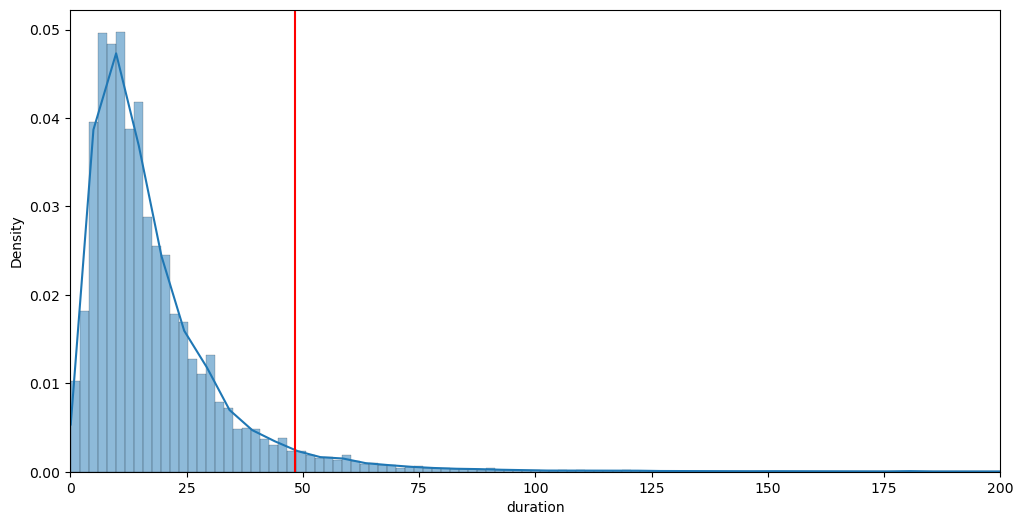

In [50]:
# overall distribution of duration
# there are repetitive peaks, likely since the temporal resolution is discrete with respect ot minutes
fig, ax = plot_density(df["duration"], bins=500)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read

Text(0.5, 0, 'log duration')

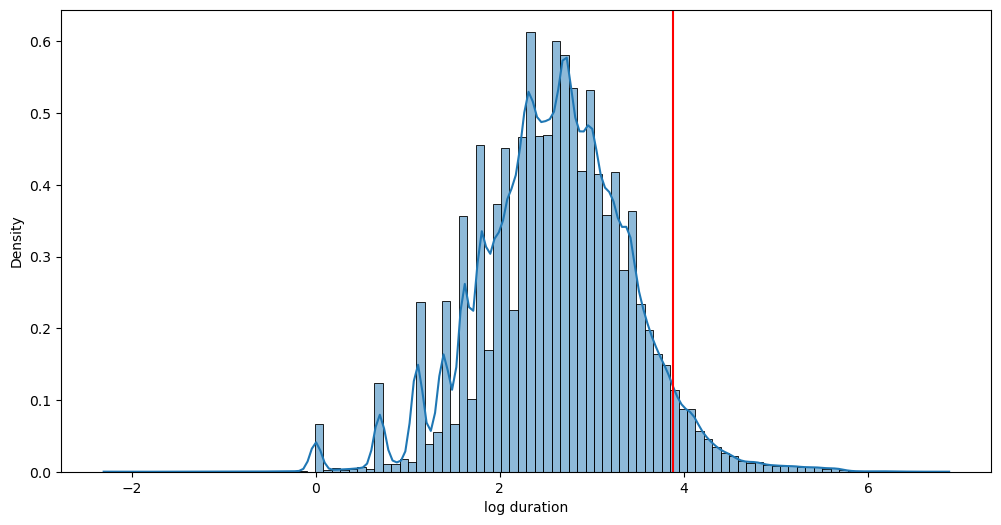

In [51]:
# overall distribution of the log of duration
fig, ax = plot_density(np.log(df["duration"]), bins=100)
ax.set_xlabel("log duration")

In [52]:
## duration analysis segmented by mode

In [53]:
def plot_mode_density(df: pd.DataFrame, key: str, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    fig, ax = plt.subplots(figsize=size)
    for mode in valid_modes: # cycle through all modes
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[key]), ax=ax, stat="density", kde=True, label=mode, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[key]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot
    return fig, ax

In [54]:
def show_summaries(df: pd.DataFrame, key: str, percentile=0.95): # show normal summaries for each mode side by side
    res = []
    p = [0.25, 0.5, 0.75]
    p.append(percentile)
    for mode in valid_modes:
        group = df[df["mode"] == mode]
        res.append(group[key].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = valid_modes
    return x

In [55]:
show_summaries(df, "duration")

,Car,Bike/Scooter,Walk,Transit
count,380027.000000,7692.000000,49670.000000,11269.000000
mean,18.652677,23.616316,16.067523,35.239585
std,21.940639,25.960970,18.711005,28.008861
min,0.100000,0.600000,0.100000,0.200000
25%,8.100000,9.000000,6.200000,18.000000
50%,13.800000,16.000000,11.300000,30.000000
75%,22.100000,29.000000,19.200000,45.000000
95%,46.300000,66.045000,42.000000,77.000000
max,971.000000,325.800000,325.000000,570.000000


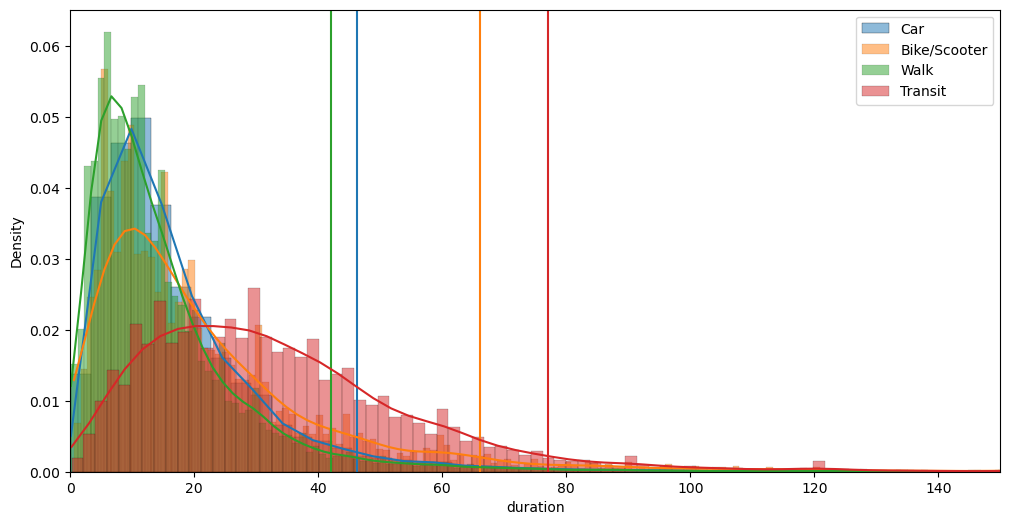

In [56]:
# plot of densities of all modes overlayed on top of one another
fig, ax = plot_mode_density(df, "duration")
ax.set_xlim(left=0, right=150)
plt.legend()

takeaways:

- durations tend to be right-skewed; people prefer shorter durations
- walk durations tend to be the shortest, followed by car, biking, and transit in that order
- there is small bias in durations as it is semi-categorical, with multiple peaks/non-continuous distribution
- the transit duration distribution deviates significantly from the other modes--transit riders are less sensitive to duration
- there remain some duration outliers
- possibly drop duration in favor of distance

further analysis:
- trip duration as a percentage of the total trip time

### difference between non-driving trip durations with corresponding driving trip duration

In [58]:
# overall

difference_with_car_duration = df[(df["mode"] != "Car") & (df["mode"].isin(valid_modes))]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] != "Car") & (df["mode"].isin(valid_modes))]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

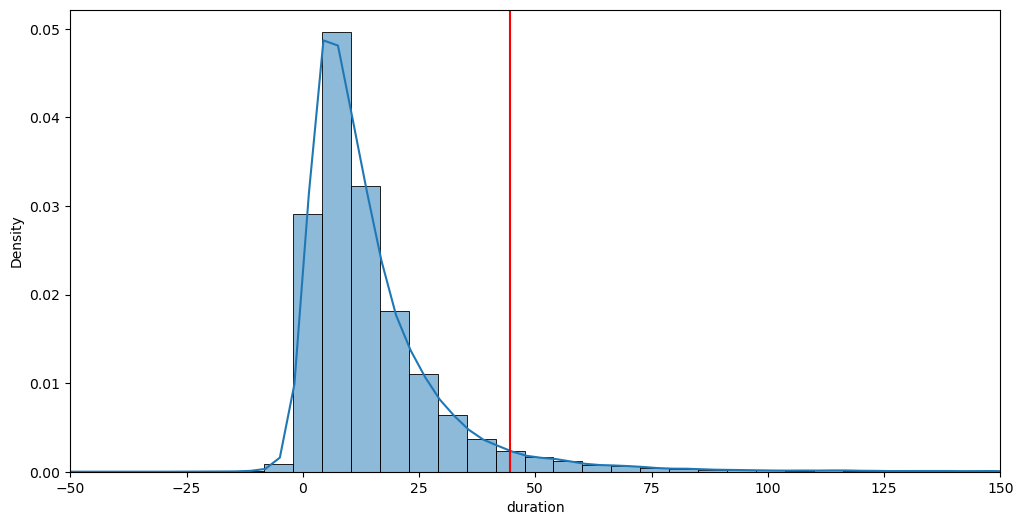

In [59]:
fig, ax = plot_density(difference_with_car_duration)
ax.set_xlim(left=-50, right=150)

In [60]:
difference_with_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    68631.000000
mean        15.613932
std         20.387016
min        -51.798333
25%          5.253333
50%         10.473333
75%         19.025833
95%         44.460000
max        570.000000
Name: duration, dtype: float64

In [61]:
# percent of all non-car trips that are faster than car
(difference_with_car_duration <= 0).sum() / len(difference_with_car_duration)

0.023138231994288296

In [62]:
# bike vs car

In [63]:
# for each bike trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these bikers tradeoff between car & bike duration
bike_minus_car_duration = df[df["mode"] == "Bike/Scooter"]["duration"] - (car.set_index("trip_id").loc[df[(df["mode"] == "Bike/Scooter")]["trip_id"].values].duration_seconds / 60).values

In [64]:
# not sure if it would be feasible to switch to bike if car is 53 minutes faster
# self sampling likely plays a role -- maybe adopt a smaller percentile to adjust?
bike_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    7692.000000
mean       16.771497
std        23.381498
min       -11.326667
25%         5.093333
50%        10.267500
75%        19.401667
95%        52.891583
max       303.550000
Name: duration, dtype: float64

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='duration', ylabel='Density'>)

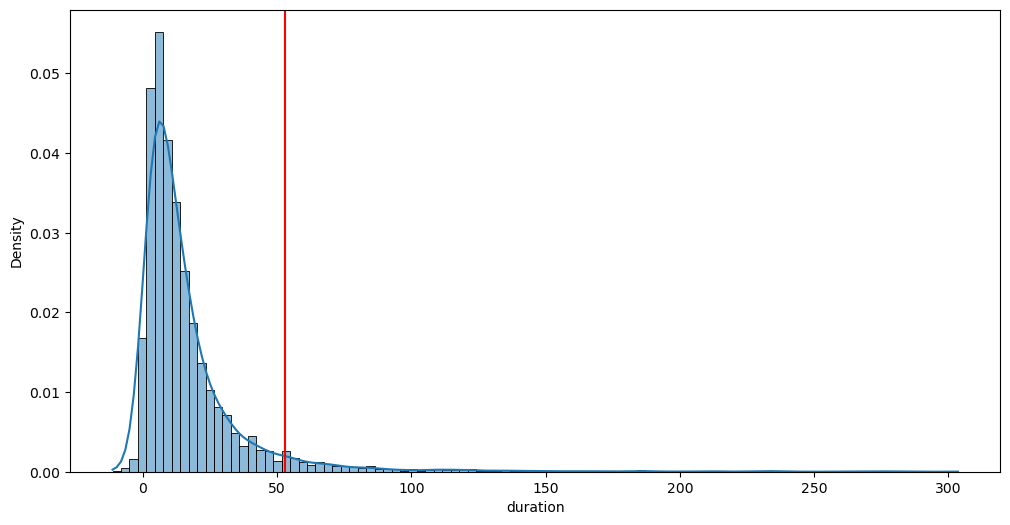

In [65]:
plot_density(bike_minus_car_duration)

In [66]:
# transit vs car

In [67]:
# for each transit trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these transit riders tradeoff between car & transit duration

transit_minus_car_duration = df[df["mode"] == "Transit"]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] == "Transit")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 200.0)

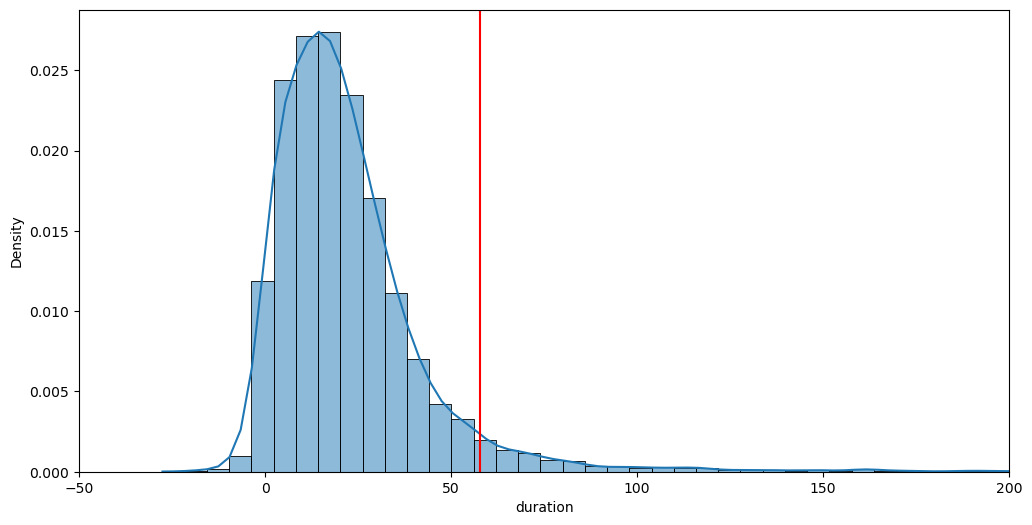

In [68]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(transit_minus_car_duration)
ax.set_xlim(left=-50, right=200)

In [69]:
transit_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    11269.000000
mean        23.016116
std         25.157686
min        -27.603333
25%          9.320000
50%         18.240000
75%         29.435000
95%         57.840000
max        570.000000
Name: duration, dtype: float64

In [70]:
# walk vs car

In [71]:
# for each walk trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how walkers tradeoff between car & walk duration

walk_minus_car_duration = df[df["mode"] == "Walk"]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] == "Walk")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

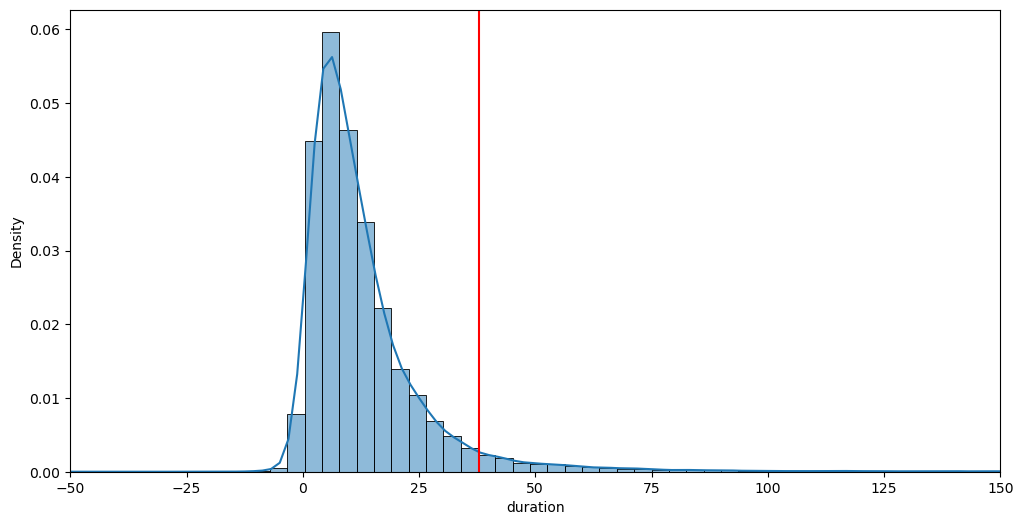

In [72]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(walk_minus_car_duration)
ax.set_xlim(left=-50, right=150)

In [41]:
walk_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    50134.000000
mean        13.849159
std         18.130597
min        -51.665000
25%          5.036667
50%          9.444167
75%         16.567917
95%         38.075750
max        321.598333
Name: duration, dtype: float64

duration difference takeaways

- the distributions for duration difference between mode and car are remarkably similar, with 95 percnetiles around 40-60
- none of these modes can beat out car (and it doesn't even seem close--the amount of trips in each mode where this mode is faster is like 1% for each), so there are some other factors other than duration that drive these people to use these modes
    - this could be due to selection bias -- people who use these modes are "enthusiasts," so a smaller percentile may be needed to account for this

further analysis
- could try a duration percentage analysis as well to standardize duration magnitudes

### difference between driving trip duration with each mode duration

In [ ]:
# car trip duration - corresponding bike duration

In [99]:
# for each car trip, find time needed to do it on bike & subtract it from the duration
# - means bike is longer & vice versa
car_duration_minus_bike = df[df["mode"] == "Car"]["duration"] - (bike.set_index("trip_id").loc[df[df["mode"] == "Car"]["trip_id"].values]["duration_seconds"] / 60).values

In [100]:
car_duration_minus_bike.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    380027.000000
mean       -127.118931
std         149.888853
min       -2208.688333
25%        -162.145000
50%         -77.953333
75%         -38.220000
95%          -8.156667
max         849.526667
Name: duration, dtype: float64

(-1000.0, 500.0)

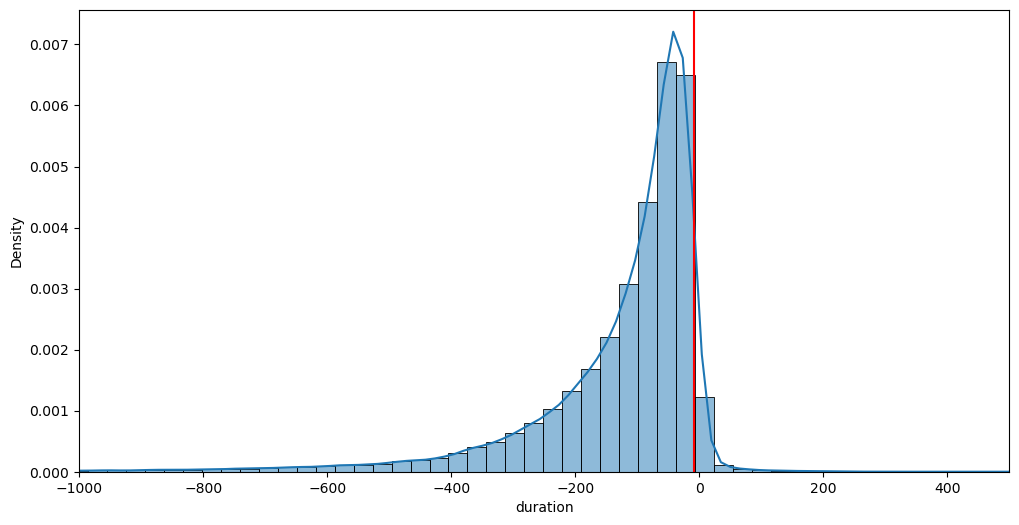

In [88]:
# most car trips are faster than corresponding bike ones but they do seem to cluster around 0 (parity)
fig, ax = plot_density(car_duration_minus_bike)
ax.set_xlim(left=-1000, right=500)

In [ ]:
# car trip duration - corresponding walk duration

In [123]:
# for each car trip, find time needed to do it walking & subtract it from the duration
# - means bike is longer & vice versa
car_duration_minus_walk = df[df["mode"] == "Car"]["duration"] - (walk.set_index("trip_id").loc[df[df["mode"] == "Car"]["trip_id"].values]["duration_seconds"] / 60).values

In [96]:
car_duration_minus_walk.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    380027.000000
mean       -112.348050
std         153.128059
min       -2038.931667
25%        -146.207500
50%         -58.236667
75%         -21.366667
95%          -0.143333
max         850.415000
Name: duration, dtype: float64

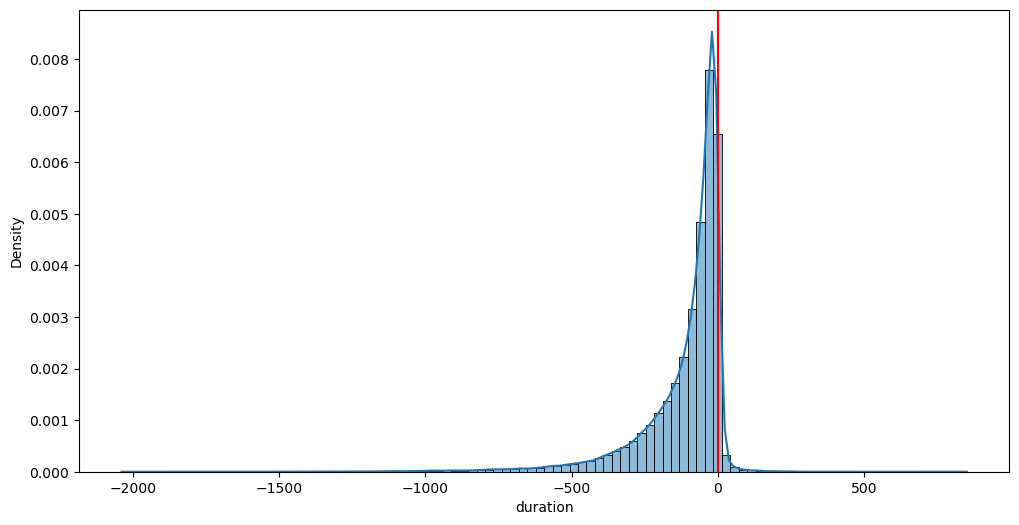

In [124]:
# about the same as bike? but slightly more left-heavy
fig, ax = plot_density(car_duration_minus_walk)
ax.set_xlim(left=-1000, right=500)

In [ ]:
# car trip duration - corresponding transit duration

In [117]:
# for each car trip, find time needed to do it via transit & subtract it from the duration (if such a time is found)
# - means bike is longer & vice versa
car_duration_minus_transit = df[(df["mode"] == "Car") & (df["trip_id"].isin(transit_grouped["trip_id"]))]["duration"] - (transit_grouped.loc[df[(df["mode"] == "Car") & (df["trip_id"].isin(transit_grouped["trip_id"]))]["trip_id"].values]["duration"]).values

In [118]:
car_duration_minus_transit.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    144283.000000
mean        -64.725463
std         265.182854
min       -2843.300000
25%         -31.666667
50%         -16.900000
75%          -8.666667
95%           3.366667
max         735.050000
Name: duration, dtype: float64

(-2000.0, 500.0)

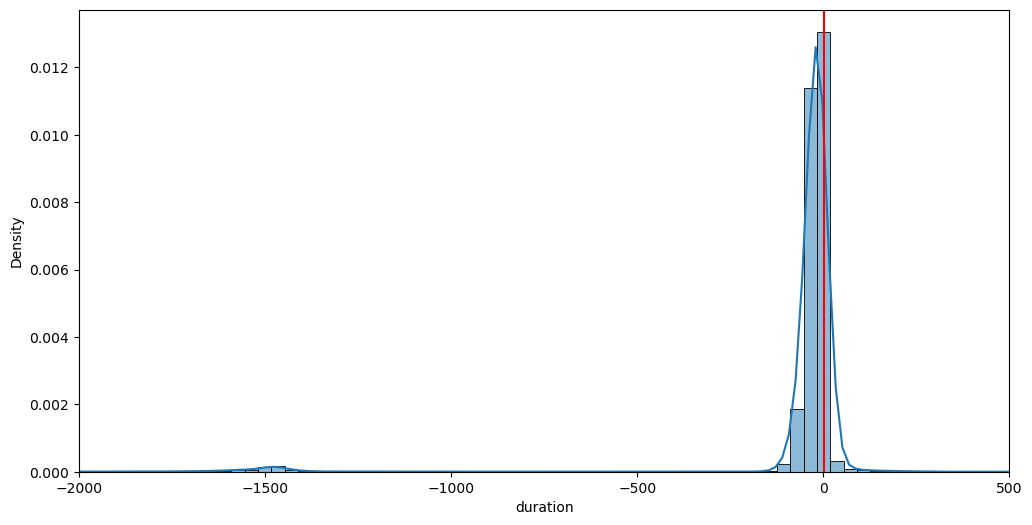

In [122]:
# this is significant different from car/biking; much more clustered around 0 aside from a small cluster near -1500
# have to note that some transit times were left out--could be systemic/due to previous filtering
fig, ax = plot_density(car_duration_minus_transit)
ax.set_xlim(left=-2000, right=500)

In [ ]:
# car minus best

In [138]:
# assume no transit trip means missing and 10000 duration
car_duration_minus_transit_cmp = car_duration_minus_transit.reindex(car_duration_minus_bike.index).fillna(10000)

In [150]:
alt_mode_duration_best = pd.concat([car_duration_minus_bike, car_duration_minus_transit_cmp, car_duration_minus_walk], axis=1).apply(min, axis=1)

In [151]:
alt_mode_duration_best.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    380027.000000
mean       -152.018362
std         222.122715
min       -2843.300000
25%        -176.298333
50%         -82.650000
75%         -40.628333
95%         -10.865500
max         849.526667
dtype: float64

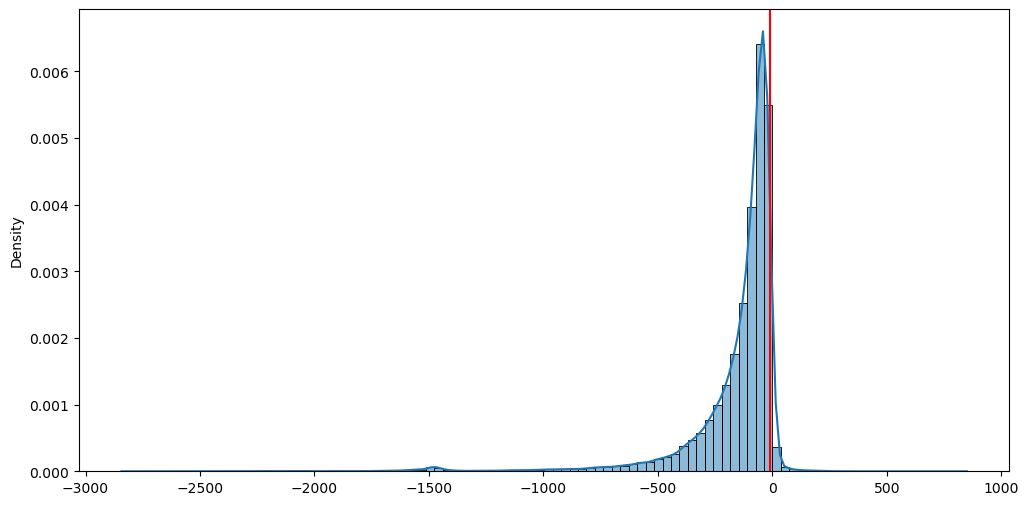

In [153]:
# seems to roughly follow transit distribution
fig, ax = plot_density(alt_mode_duration_best)

### distance analysis

In [154]:
# overall

In [155]:
# summary statistics
df["distance"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    454181.000000
mean          6.242626
std           8.264772
min           0.010238
25%           1.165764
50%           3.207450
75%           8.072440
95%          22.109606
max          99.978130
Name: distance, dtype: float64

(0.0, 50.0)

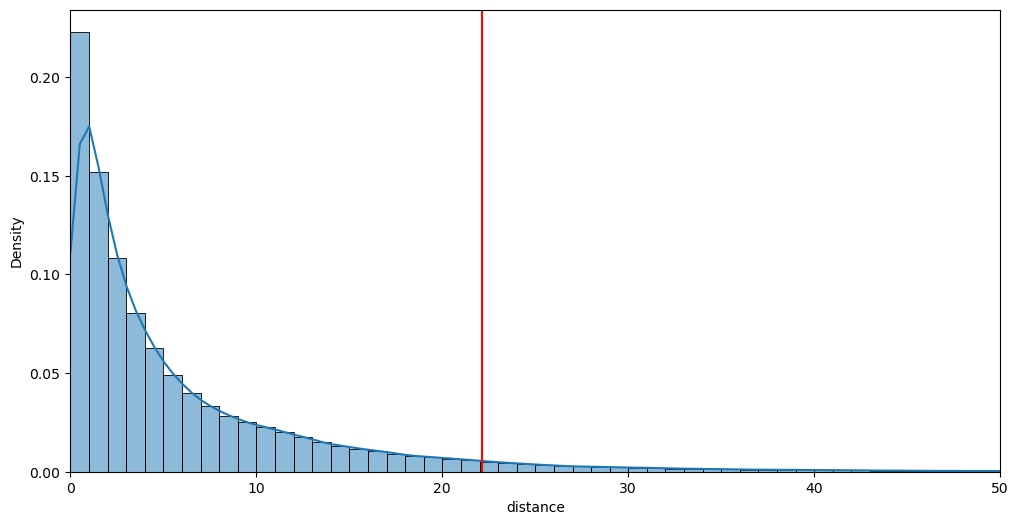

In [156]:
# distribution
fig, ax = plot_density(df["distance"])
ax.set_xlim(left=0, right=50) # max is 99, cut off about half

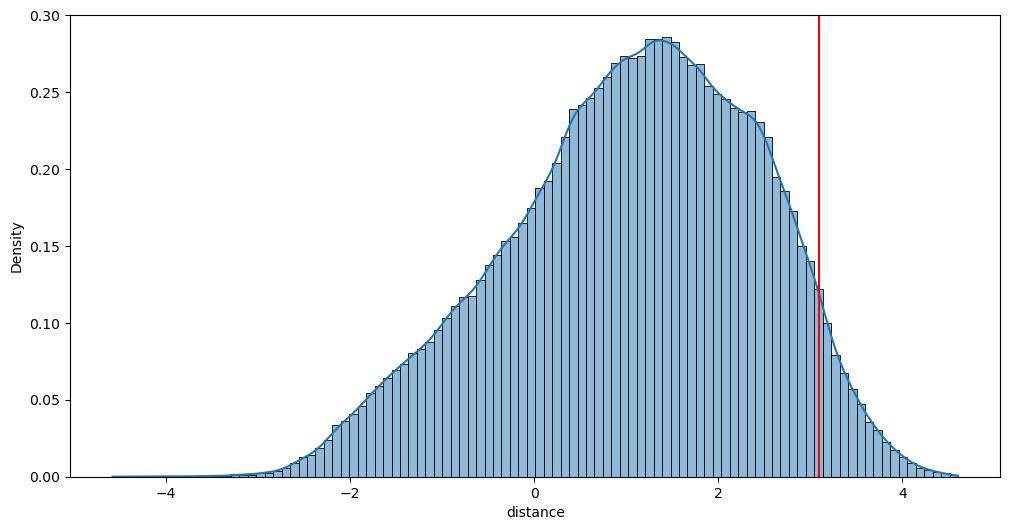

In [157]:
# log distance distribution
# compared with the overall distribution, we see more resolution in the shorter distance trips, which make up a significant portion of all trips
fig, ax = plot_density(np.log(df["distance"]))

In [46]:
# segmented by mode

In [158]:
show_summaries(df, key="distance")

,Car,Bike/Scooter,Walk,Transit
count,380027.000000,7692.000000,49670.000000,11269.000000
mean,7.029822,3.239614,0.703522,6.974695
std,8.605750,4.222073,1.243842,7.471775
min,0.010271,0.057926,0.010238,0.056540
25%,1.650660,0.834450,0.217010,2.156030
50%,3.931170,1.857828,0.400441,4.422960
75%,9.216220,4.057700,0.764565,8.848897
95%,23.481493,10.543824,2.047349,22.073538
max,99.978130,80.358668,55.865006,70.046313


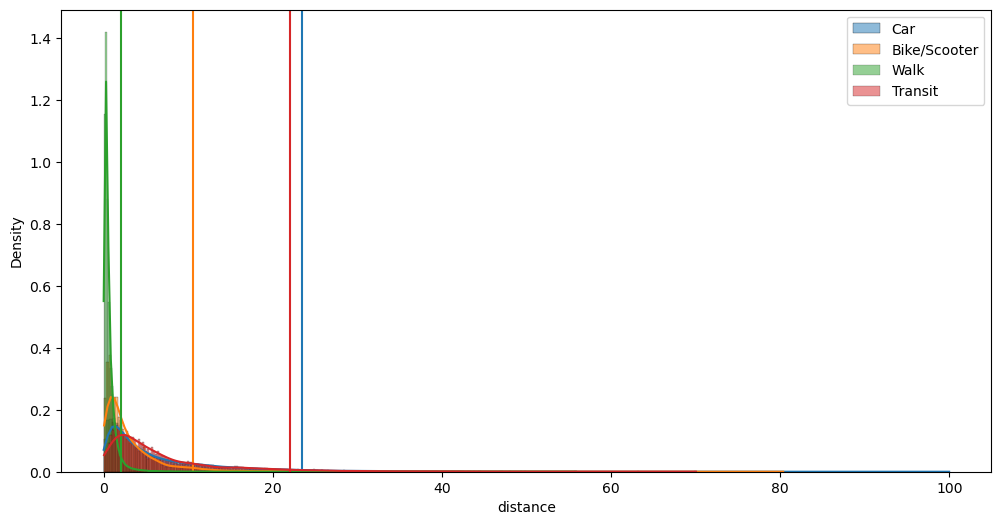

In [159]:
# raw distance distribution (miles)
fig, ax = plot_mode_density(df, key="distance") # this is meaningless
plt.legend()

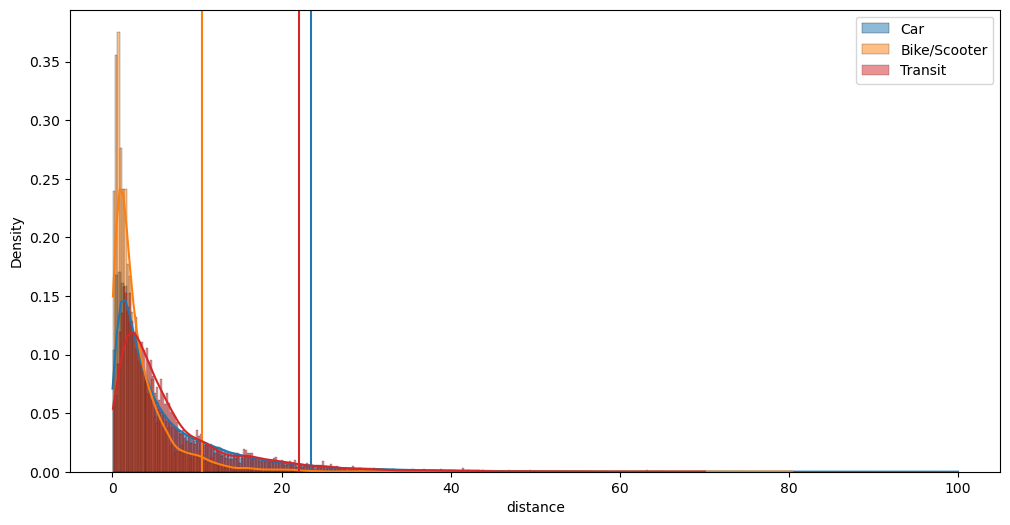

In [160]:
# raw distance distribution (miles) with walk omitted
fig, ax = plot_mode_density(df[df["mode"] != "Walk"], key="distance")
plt.legend()

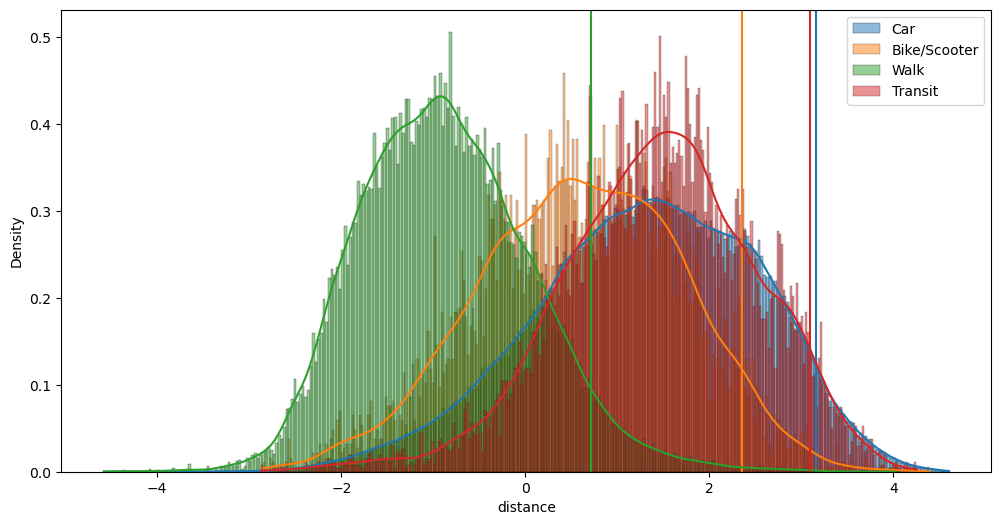

In [161]:
# log distance distribution
fig, ax = plot_mode_density(df, key="distance", function=np.log)
plt.legend()

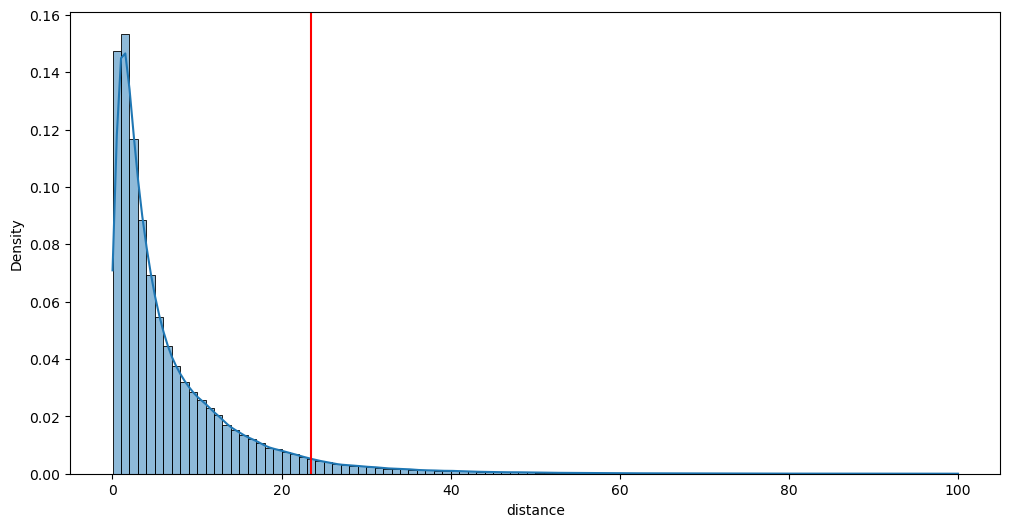

In [162]:
# car distance distribution
fig, ax = plot_density(df[df["mode"] == "Car"]["distance"])

(0.0, 35.0)

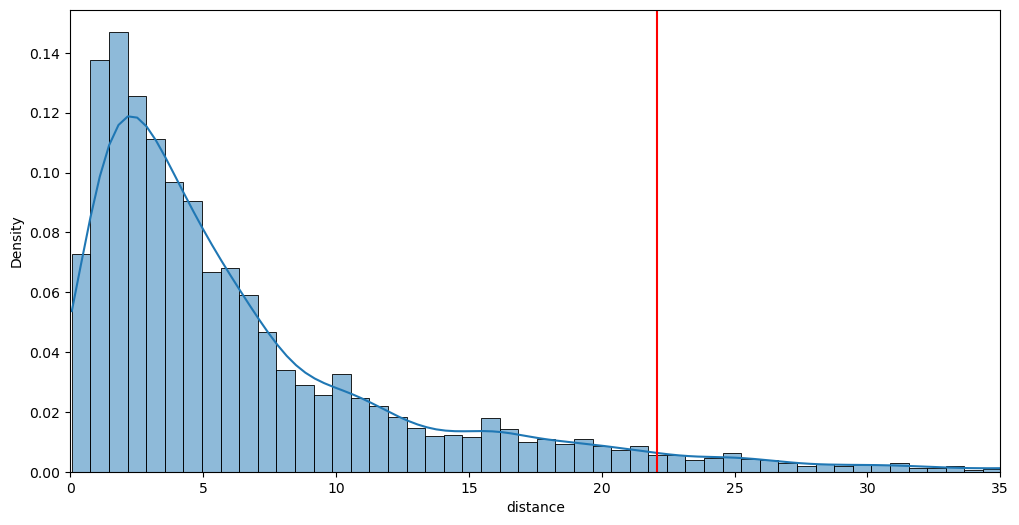

In [163]:
# transit distance distribution
fig, ax = plot_density(df[df["mode"] == "Transit"]["distance"])
ax.set_xlim(left=0, right=35)

(0.0, 4.0)

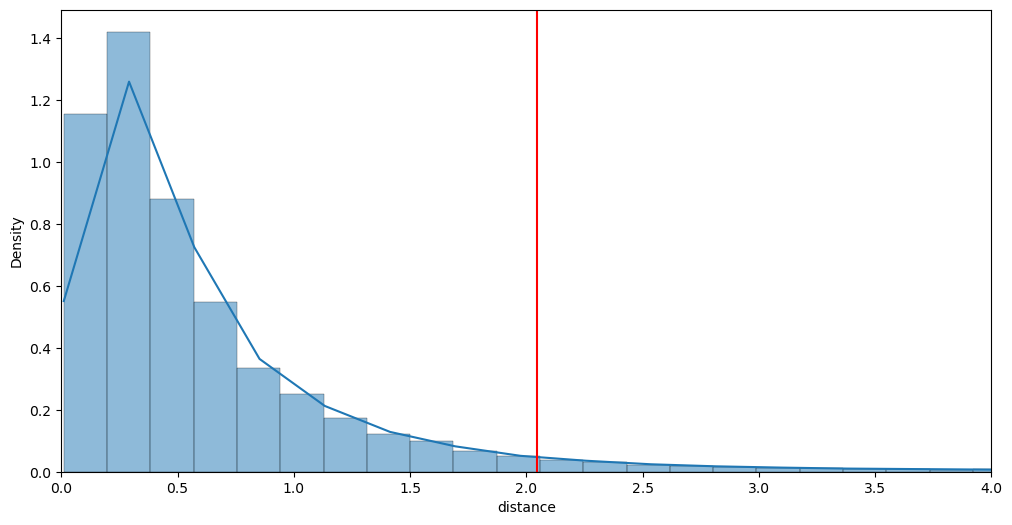

In [164]:
# walk distance distribution
fig, ax = plot_density(df[df["mode"] == "Walk"]["distance"], bins=300)
ax.set_xlim(left=0, right=4)

(0.0, 20.0)

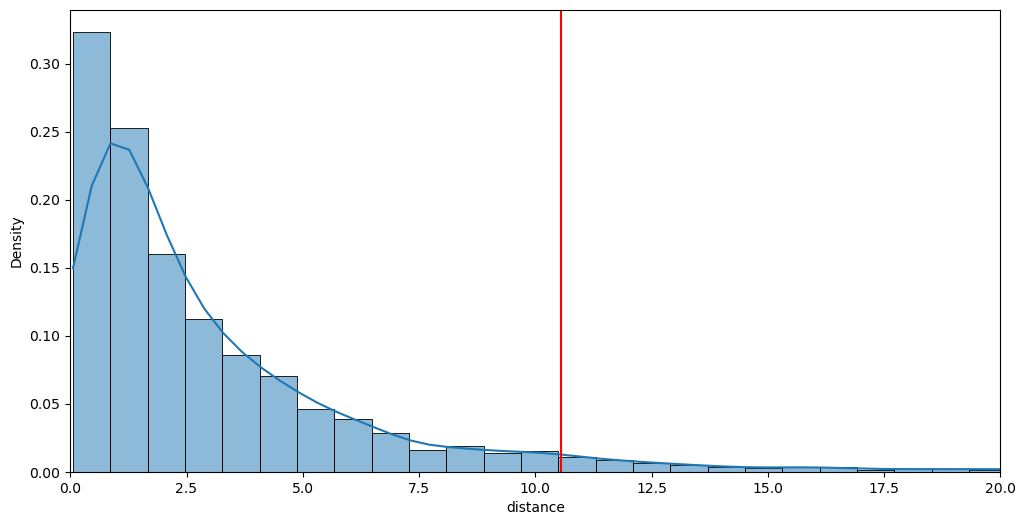

In [165]:
# bike distnace distribution
fig, ax = plot_density(df[df["mode"] == "Bike/Scooter"]["distance"])
ax.set_xlim(left=0, right=20)

distance takeaways

- honestly pretty straight forward, not anything surprising
- more continuous than duration, has a continuous decline from 0 distance trips, very much right skewed
    - people prefer shorter distance trips
- car and transit distance distributions are relatively similar -- transit & car riders have relatively similar sensitivies to distance
- walk trips are generally about 1 mile or less
- bike/scooter trips are a middle ground between car/transit and walk

further analysis
- we could do a distance vs car analysis but this probably wouldn't show much--difference between walking around a square and cutting through the middle
- maybe distance in certain areas? like cbd vs suburban or something


### season

(i don't think we can get weather)

In [166]:
df["month"] = df["travel_date"].str[5:7]

In [167]:
def map_to_season(month):
    # can change to a more granular definition
    match month:
        case '12' | '01' | '02':
            return "winter"
        case '03' | '04' | '05':
            return "spring"
        case '06' | '07' | '08':
            return "summer"
        case _:
            return "autumn"

In [168]:
df["season"] = df["month"].apply(map_to_season)
df["season"] = df["month"].apply(map_to_season)

<Axes: xlabel='season', ylabel='count'>

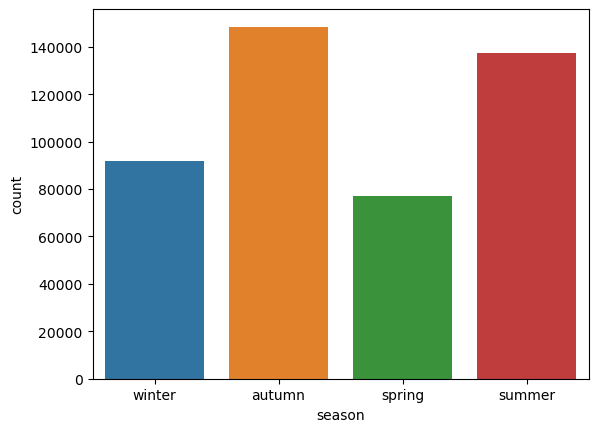

In [169]:
# distribution of season
# WARNING: this could be biased due to the timespan of the data collection -- some season may have been cut short
sns.countplot(x="season", data=df)

In [170]:
# season distribution by mode

In [171]:
# mode share
def plot_mode_barplot_pct_total(df: pd.DataFrame, key: str, mode:str, func=lambda x: x, figsize=(7, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=df[key].value_counts().sort_index().index, y=func(df[df["mode"] == mode][key].value_counts().sort_index()), ax=ax)
    return fig, ax

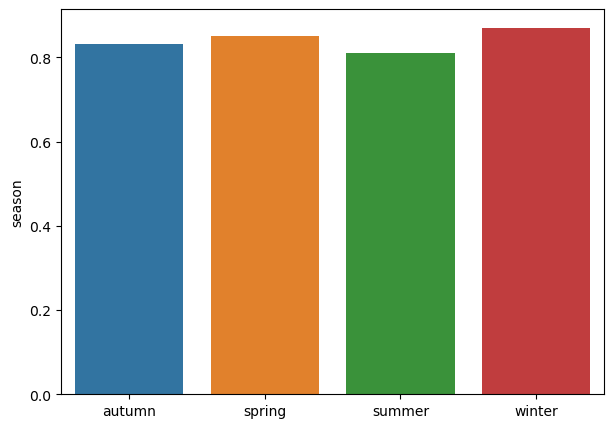

In [172]:
# car seasons
# little variation in car trip % between seasons aside from a slight dip in the summer and slight bump in winter
# thsi represents the % of trips in each season that were by car
fig, ax = plot_mode_barplot_pct_total(df, "season", "Car", lambda x: x / df["season"].value_counts())

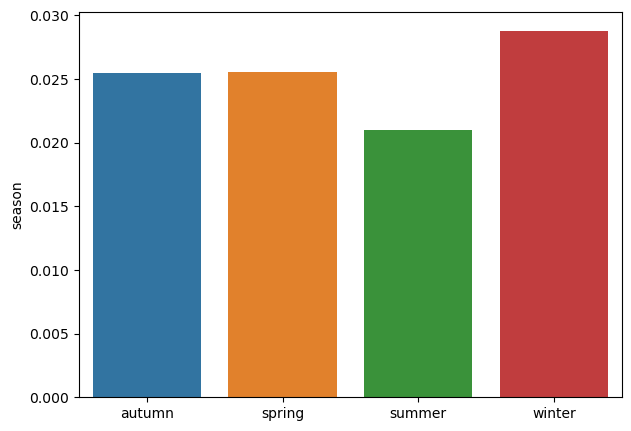

In [173]:
# transit seasons
# significant summer dip & somewhat significant winter bump (possibly due to unsafe conditions otherwise?)
fig, ax = plot_mode_barplot_pct_total(df, "season", "Transit", lambda x: x / df["season"].value_counts())

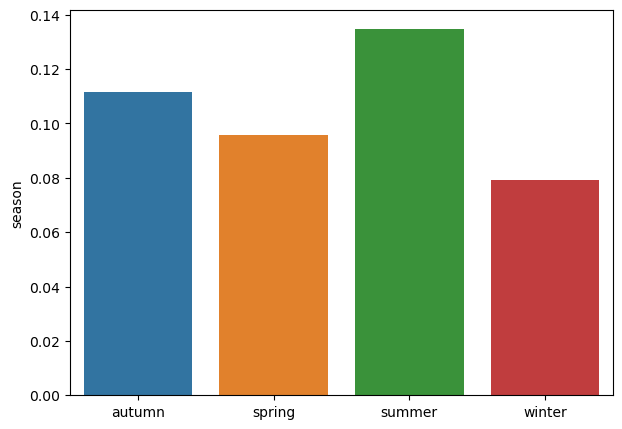

In [174]:
# walk seasons
# significant summer bump & significant winter dip
fig, ax = plot_mode_barplot_pct_total(df, "season", "Walk", lambda x: x / df["season"].value_counts())

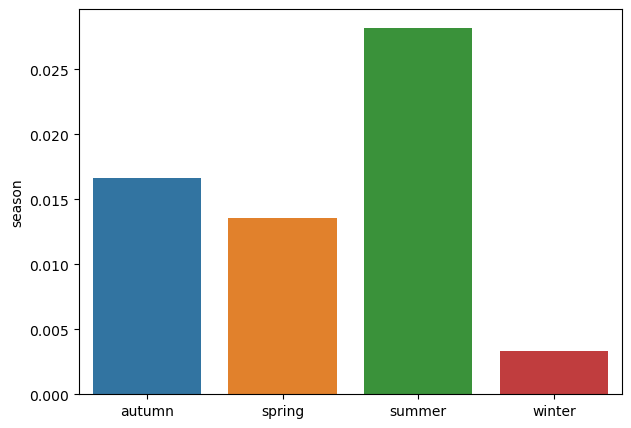

In [175]:
# bike season
# very significant summer bump & very significant winter dip
# basically walk but more extreme variation
fig, ax = plot_mode_barplot_pct_total(df, "season", "Bike/Scooter", lambda x: x / df["season"].value_counts())

In [ ]:
# segmentation by month

<Axes: xlabel='month', ylabel='count'>

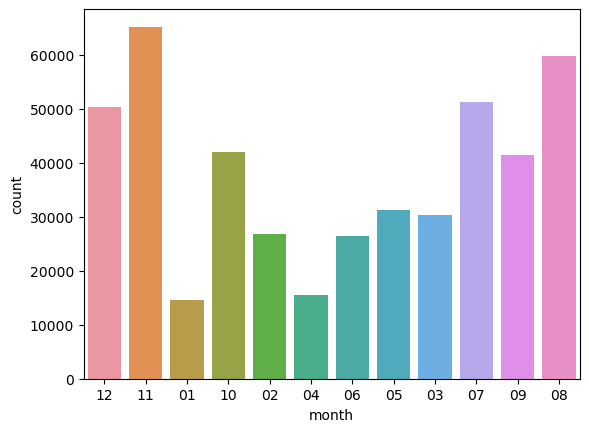

In [177]:
# distribution of month
# WARNING: this could be biased due to the timespan of the data collection -- some season may have been cut short
sns.countplot(x="month", data=df)

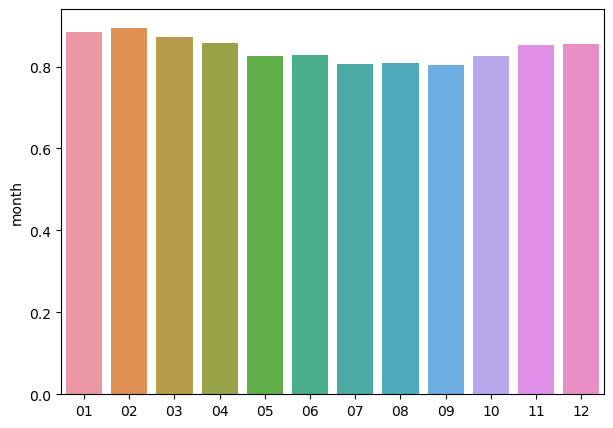

In [178]:
# car months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Car", lambda x: x / df["month"].value_counts())

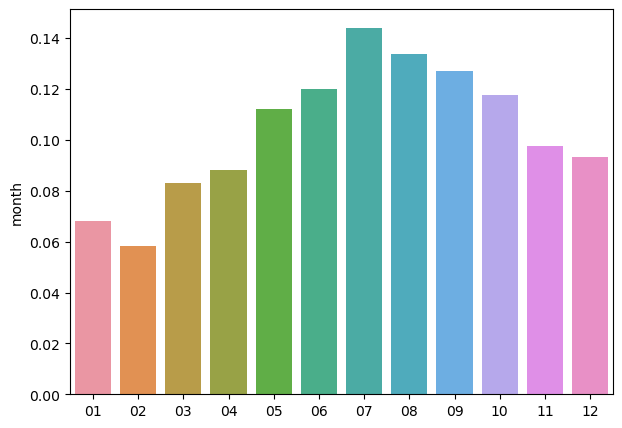

In [179]:
# walk months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Walk", lambda x: x / df["month"].value_counts())

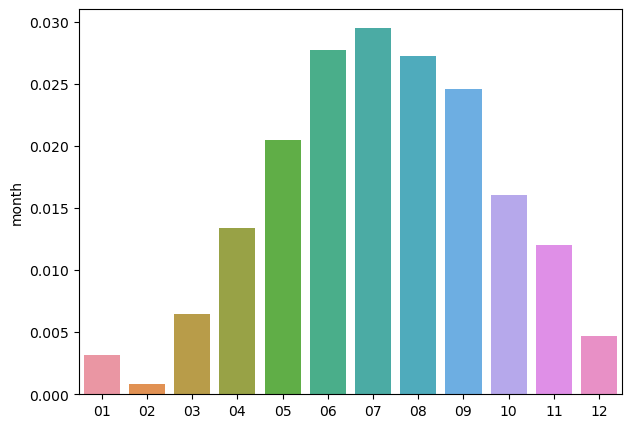

In [180]:
# bike months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Bike/Scooter", lambda x: x / df["month"].value_counts())

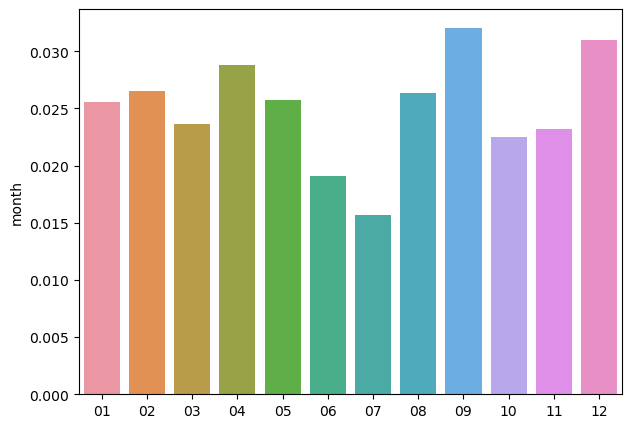

In [181]:
# transit months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Transit", lambda x: x / df["month"].value_counts())

takeaways

- seasons do seem to play a large part in the relative proportions of mode trips for non-driving modes
    - comparing relative proportions in distance should be able to handle the sampling timing bias
    - this effect is very pronounced for walking and biking
    - this effect is seen more granularly with month segmentation

future analysis
- how do we apply a 95% rule for categorical variables? -- probably need an alternative feasibility indicator
    - could just cut out extreme dips -- e.g., people don't bike in winter
- more granular season definitions
- include weather/ temperature (continuous data) / wind speed / other climate data somehow
    - could just extract average temperatures of the area by day and merge

### daylight hours - yes or no

In [182]:
def plot_multi_barplot(df: pd.DataFrame, x: str, y: str, figsize=(7, 5), order=None):
    # plot normalized bar plot of the values in each mode side by side
    fig, ax = plt.subplots(figsize=figsize)
    if y == "mode": 
        df = df[df["mode"].isin(valid_modes)]
    (df
     .groupby(y)[x]
     .value_counts(normalize=True)
     .mul(100)
     .rename("percent")
     .reset_index()
     .pipe((sns.barplot, "data"), x=x, y="percent", hue=y, ax=ax, order=order)
    )
    
    return fig, ax

In [183]:
df["start_hour"] = df["depart_time"].str[:2]
df["end_hour"] = df["arrive_time"].str[:2]

In [184]:
# define daylight trips to start after 6 AM & end before 6 PM
# currently can't easily account for changes of this with dst/time of year
df["during_daylight"] = np.where((df["start_hour"].astype(int) >= 6) & (df["end_hour"].astype(int) <= 18), 1, 0)

<Axes: xlabel='during_daylight', ylabel='count'>

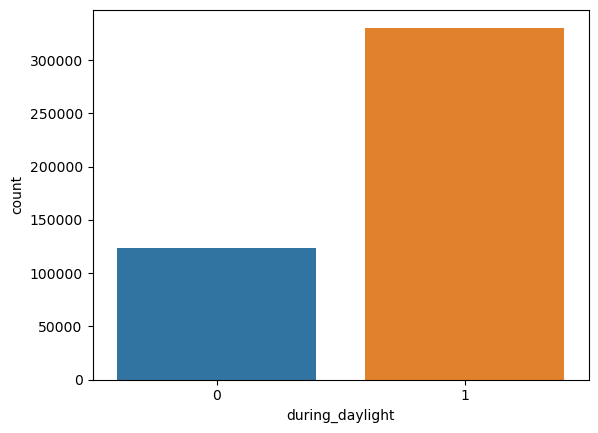

In [185]:
# distribution of trips w.r.t occurring wthin daylight hours
# majority are within daylight hours
# this doesn't have the problem as with seasons as daylight occurs on a daily basis, which the survye likely captures
sns.countplot(x="during_daylight", data=df)

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='during_daylight', ylabel='percent'>)

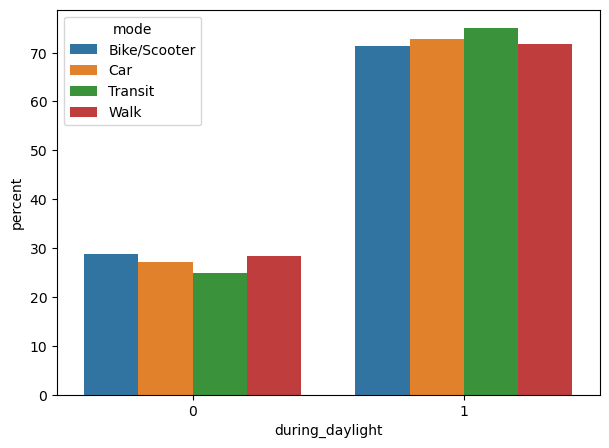

In [186]:
# bar plot of the % of trips in a given mode that occur during/not during daylight side by side for all modes
# inexplicably, there are more walk/biking trips at nighttime
plot_multi_barplot(df, "during_daylight", "mode")

In [187]:
# try another metric -- daylight to nighttime ratio of trips

In [188]:
print("Car daylight to nighttime trip ratio")
print(df[df["mode"] == "Car"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Car"]["during_daylight"].value_counts().sort_index()[0])
print()

print("Transit daylight to nighttime trip ratio")
print(df[df["mode"] == "Transit"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Transit"]["during_daylight"].value_counts().sort_index()[0])
print()

print("Walk daylight to nighttime trip ratio")
print(df[df["mode"] == "Walk"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Walk"]["during_daylight"].value_counts().sort_index()[0])
print()

print("Bike daylight to nighttime trip ratio")
print(df[df["mode"] == "Bike/Scooter"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Bike/Scooter"]["during_daylight"].value_counts().sort_index()[0])
print()

Car daylight to nighttime trip ratio
2.679472904543826

Transit daylight to nighttime trip ratio
3.0088936321593738

Walk daylight to nighttime trip ratio
2.5377492877492878

Bike daylight to nighttime trip ratio
2.4821186057039384



takeaways

- probably don't use trip occurs at daytime as indicator
    - walk/bike trips inexplicably occur more often at night

future analysis

- figure out why this pattern is occurring
- alternative metrics?
- dynamic daytime detemrination -- dst and changes over the year

### number of passengers

In [189]:
# overall analysis

In [190]:
# parsing into integer summary statistics
df[df["num_travelers"] != "Missing"]["num_travelers"].astype(int).describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    452182.000000
mean          1.814652
std           1.162938
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
95%           4.000000
max          11.000000
Name: num_travelers, dtype: float64

In [191]:
df["num_travelers_numeric"] = np.where(df["num_travelers"] == "Missing", -1, df["num_travelers"])
df["num_travelers_numeric"] = df["num_travelers_numeric"].astype(int)

<Axes: xlabel='num_travelers_numeric', ylabel='count'>

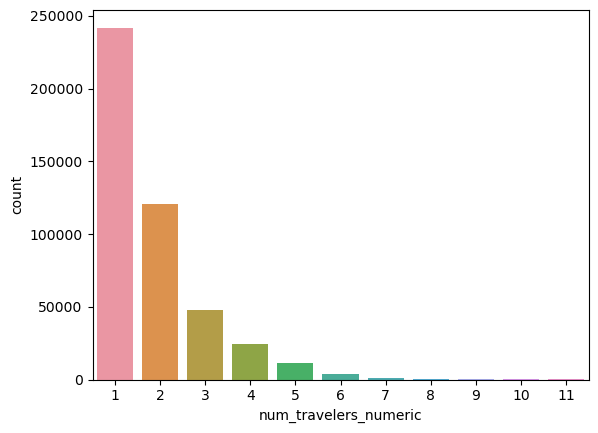

In [192]:
sns.countplot(x="num_travelers_numeric", data=df[df["num_travelers"] != "Missing"])

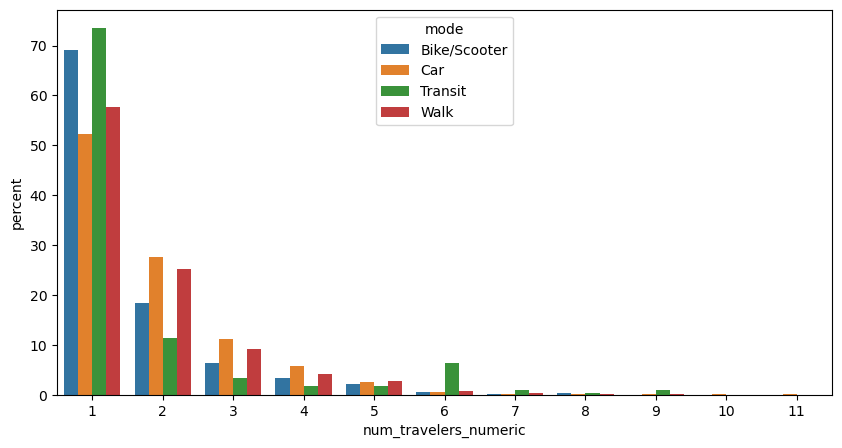

In [193]:
# side-by-side bar plot of the percentage of trips in each mode that have x travelers
# it seems car and walking are the dominant multi-traveler modes
# bike/scooter and transit are generally left-heavier, except for a seemingly random transit peak at 6 travelers
# TODO: try stacked bar chart with mode share (a la season)
fig, ax = plot_multi_barplot(df[df["num_travelers"] != "Missing"], "num_travelers_numeric", "mode", figsize=(10, 5))

In [194]:
# summary statistics of the number of travelers for eahc mode
show_summaries(df[df["num_travelers"] != "Missing"], key="num_travelers_numeric")

,Car,Bike/Scooter,Walk,Transit
count,379430.000000,7682.000000,49555.000000,11222.000000
mean,1.817426,1.537881,1.733912,1.761896
std,1.119320,1.023578,1.130963,1.648287
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000
95%,4.000000,4.000000,4.000000,6.000000
max,11.000000,8.000000,9.000000,9.000000


takeaways

- transit/biking are modes generally associated with less travelers while walking/driving are hte opposite
    - there are deviations from this trend -- e.g., the dominance of transit from 6-9 travelers (college students? or groups of people going somewhere without cars)

future analysis
- 95% rule probably won't work here -- it's not really reasonable to assume anybody with 4 travelers can just ride via bike/scooter
    - percentiles aren't also necessarily the best here -- data is ordinal, not continuous; need more robust metric for number of people
- possibly go into more detail with number of children/non-household members as well

### traveler details

In [195]:
# traveler ability to drive

In [196]:
df["can_drive"].value_counts()

Yes, drives           384157
No, does not drive     54663
Missing                15361
Name: can_drive, dtype: int64

<Axes: xlabel='can_drive', ylabel='count'>

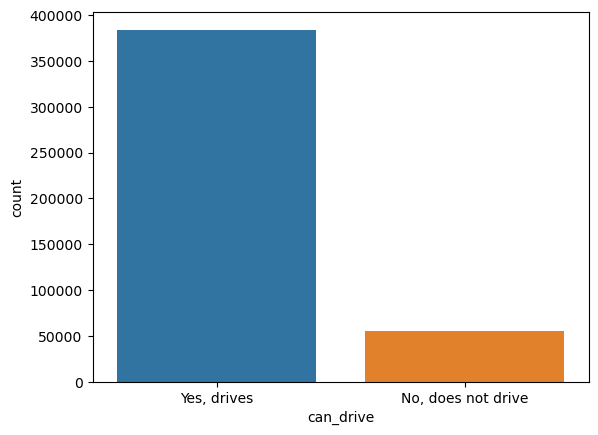

In [197]:
# bar plot of can drive vs can't drive
# most people can drive
# does htis include car ownership or just license?
sns.countplot(x="can_drive", data=df[df["can_drive"] != "Missing"])

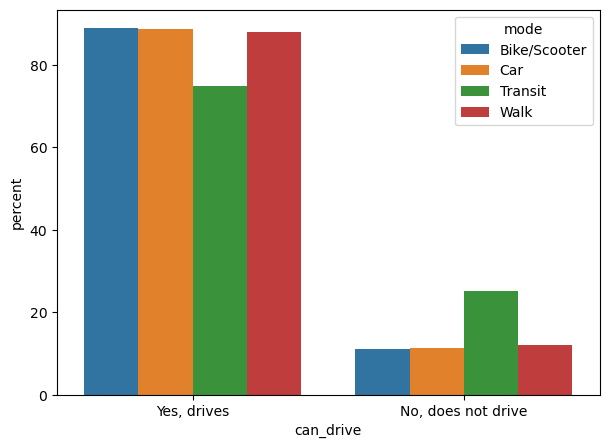

In [198]:
# side by side bar plot of the % of epople in each mode who can drive/can't drive
# relatively uniform aside from transit -- people who can drive have a lesser tendency to not use transit & vice versa
# transit may directly substitute car trips while other modes simply complement them
fig, ax = plot_multi_barplot(df[df["can_drive"] != "Missing"], "can_drive", "mode")

In [199]:
# age analysis

In [200]:
df["age"].value_counts()

35-44          58971
25-34          54719
55-64          48187
45-54          43791
35 to 44       34695
25 to 34       33172
65-74          30770
5-15           27793
55 to 64       20726
45 to 54       20686
Under 5        20396
65 to 74       16615
18-24          12439
5 to 15         8988
18 to 24        7665
75 or older     6959
75 to 84        3511
16-17           3227
16 to 17         669
85 or older      202
Name: age, dtype: int64

In [201]:
# merge the two different labeling schemes
df["age_cleaned"] = df["age"].apply(lambda x: '-'.join(x.split(" to ")))
df["age_cleaned"] = np.where(df["age_cleaned"] == "5-15", "05-15", df["age_cleaned"])
df["age_cleaned"] = np.where(df["age_cleaned"] == "Under 5", "00-05", df["age_cleaned"])

<Axes: xlabel='age_cleaned', ylabel='count'>

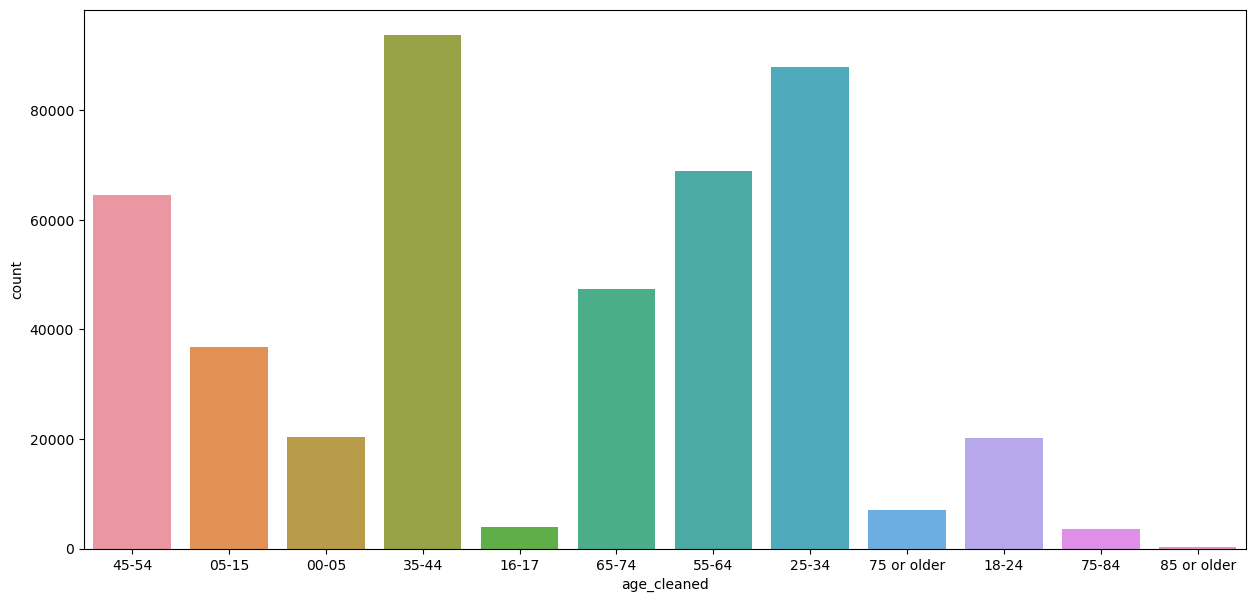

In [202]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.countplot(x="age_cleaned", data=df, ax=ax)

(<Figure size 1500x700 with 1 Axes>,
 <Axes: xlabel='age_cleaned', ylabel='percent'>)

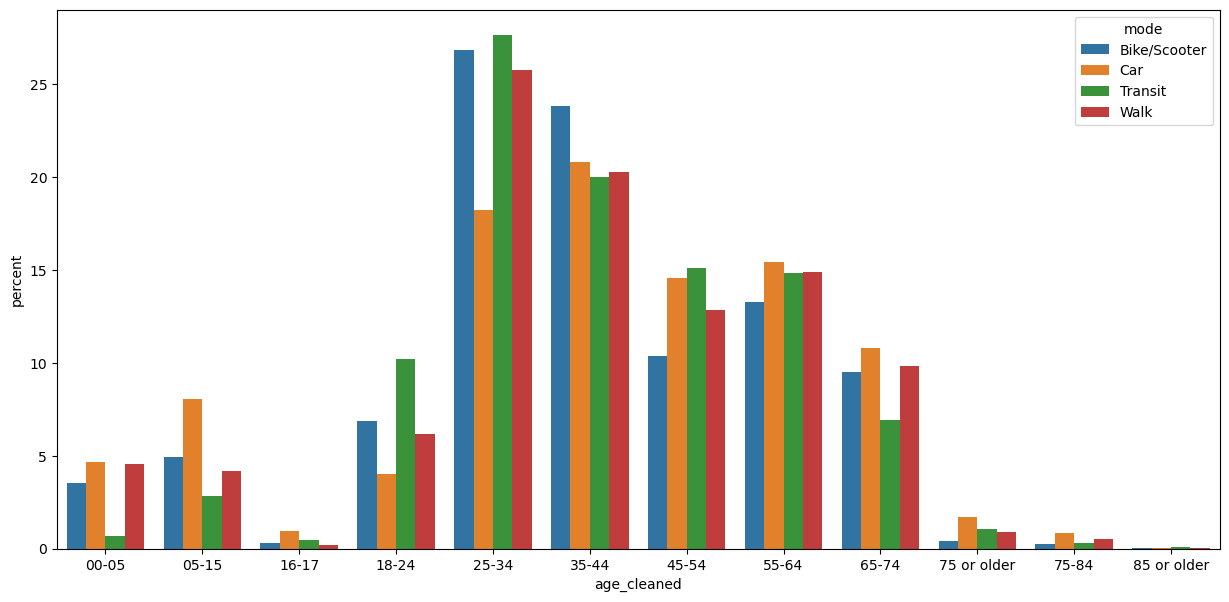

In [203]:
# side by side bar plot of the % of trips of each mode that were made by certain age groups
# generally, car usage is less dominant from 18-44, after which car becomes more dominant
# transit usage decays from a peak in 25-34
plot_multi_barplot(df, "age_cleaned", y="mode", figsize=(15, 7), order=df["age_cleaned"].value_counts().sort_index().index)

In [204]:
# age - can't really rule out anything
    # maybe old people can't bike
# one record for each person id -- both

In [205]:
# disability

In [206]:
df["disability"].value_counts()

No                       369754
Missing: Skip logic       45764
Missing                   16163
Yes                       14449
Prefer not to answer       6609
Missing: Non-response      1442
Name: disability, dtype: int64

In [207]:
# clean all missing things into one NA value
df["disability_cleaned"] = np.where(df["disability"].isin(["No", "Yes"]), df["disability"], "NA")

In [208]:
df["disability_cleaned"].value_counts()

No     369754
NA      69978
Yes     14449
Name: disability_cleaned, dtype: int64

<Axes: xlabel='disability_cleaned', ylabel='count'>

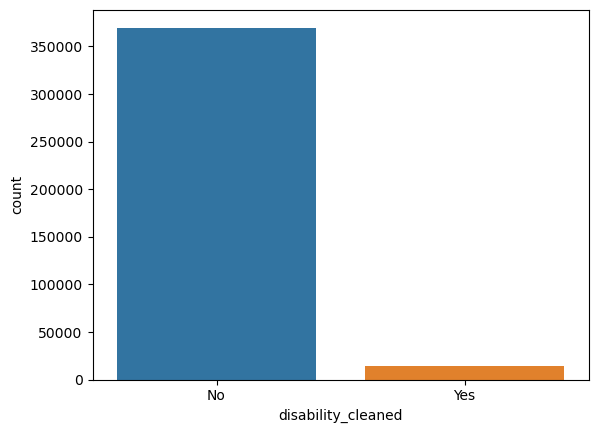

In [209]:
sns.countplot(x="disability_cleaned", data=df[df["disability_cleaned"] != "NA"])

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='disability_cleaned', ylabel='percent'>)

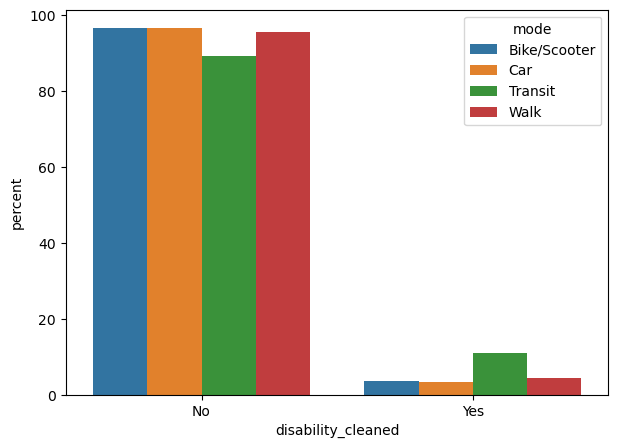

In [210]:
# side by side bar plot of the % of trips via each mode who do/do not have disabilities
# similar trend to those without cars -- those with disabilities tend to travel via transit, with everything else uniform
plot_multi_barplot(df[df["disability_cleaned"] != "NA"], "disability_cleaned", "mode")

takeaways
- those who cannot drive/are disabled have a greater likelihood of choosing transit, although not very significantly
    - there is likely some overlap between these groups
    - with these variables, all other modes are uniform -- there is something unique about transit in catering to these people
- the relationship between age & mode choice/preferences are complex, but there definitely do seem to be patterns

future analysis
- possibly explore more personal variables
- can explore the combination of personal variables with other ones
    - e.g., people with disabilities that have multiple people in their household/travel with multiple people often

### bike lts share

In [213]:
bike["lts1"] = bike["distance_meters_1"] / bike["distance_meters"]
bike["lts2"] = bike["distance_meters_2"] / bike["distance_meters"]
bike["lts3"] = bike["distance_meters_3"] / bike["distance_meters"]
bike["lts4"] = bike["distance_meters_4"] / bike["distance_meters"]

In [218]:
bike_lts_share = bike.set_index("trip_id").loc[df[df["mode"] == "Bike/Scooter"].trip_id][["lts1", "lts2", "lts3", "lts4"]]

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts1', ylabel='Density'>)

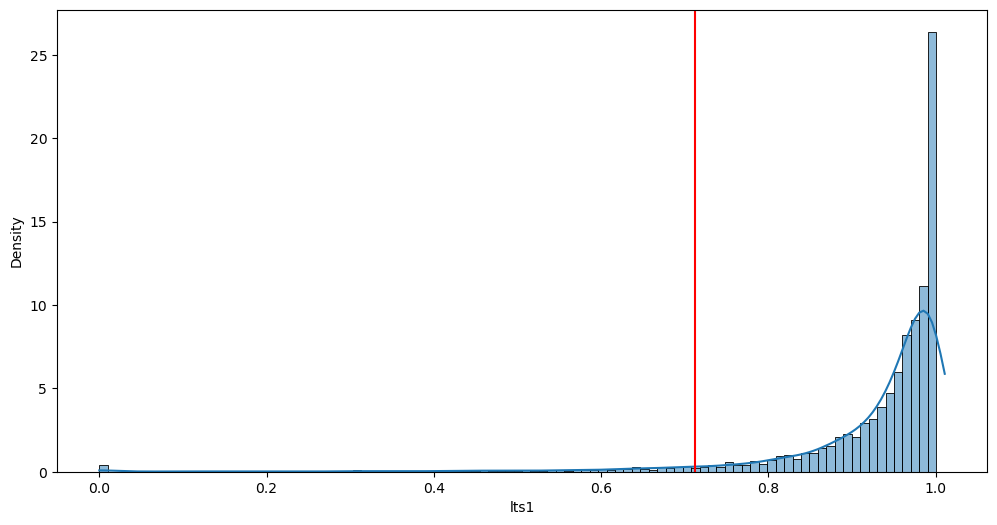

In [223]:
# distribution of % of trip taken in lts1, very right-heavy
# 0.05 percentile is effectively the 95th here
plot_density(bike_lts_share["lts1"], percentile=0.05)

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts2', ylabel='Density'>)

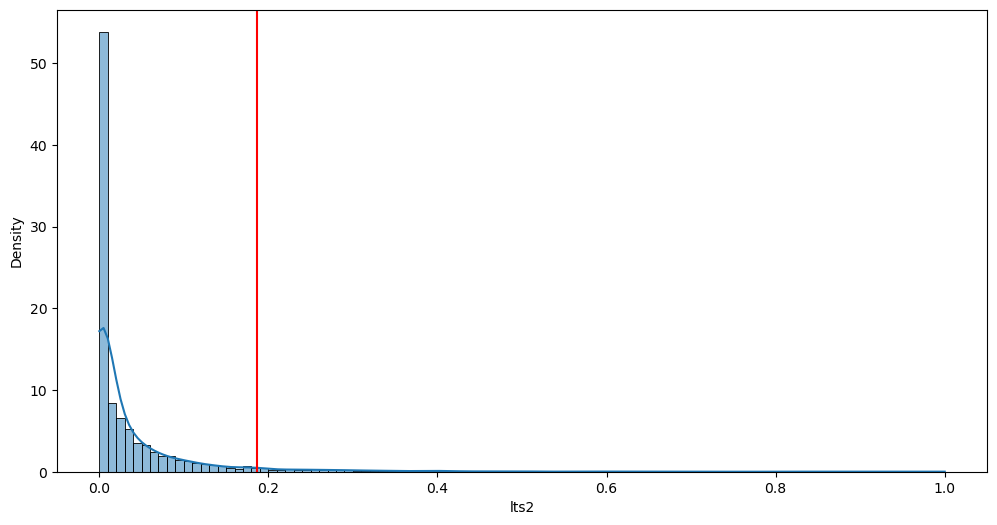

In [220]:
# distribution of % of trip taken in lts2, left-heavy
plot_density(bike_lts_share["lts2"])

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts3', ylabel='Density'>)

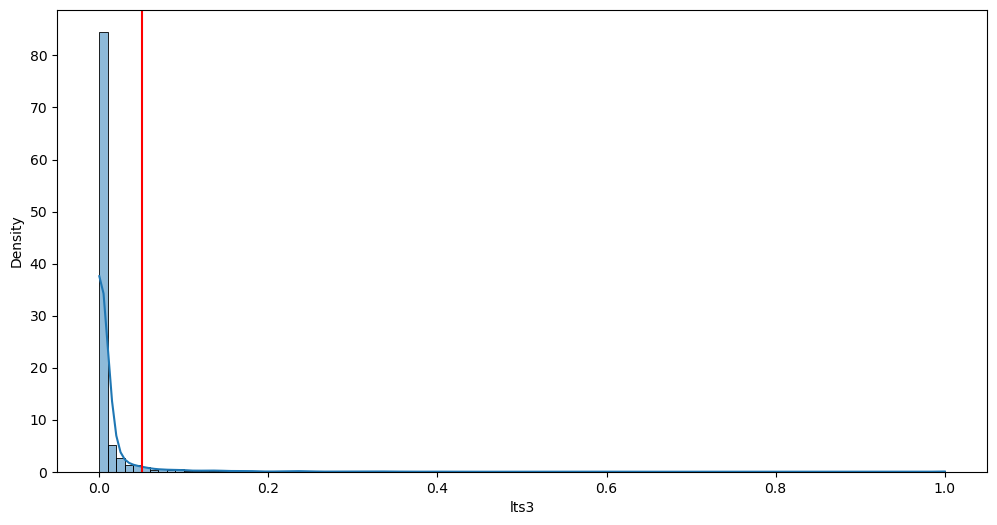

In [221]:
# distribution of % of trip taken in lts3
# like lts2 but more left-heavy
plot_density(bike_lts_share["lts3"])

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts4', ylabel='Density'>)

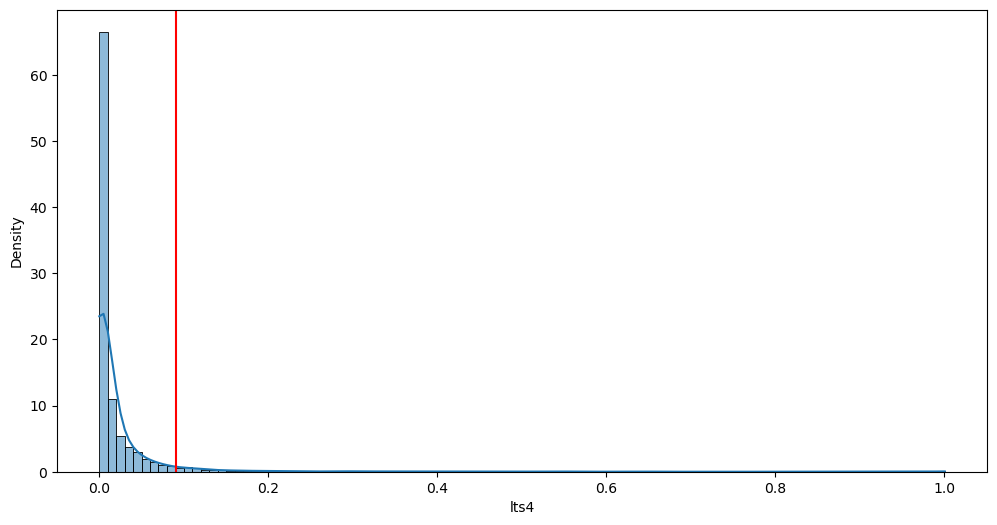

In [222]:
# distribution of % of trip taken in lts4
# like lts3 but more left-heavy
plot_density(bike_lts_share["lts4"])

takeaways

- lts is a strong measure of biking feasibility -- the vast majoirty of trips should be done in lts 1

### summary

This table indicates the % of car trips that meet each feasibility indicator independently

| Feasibility indicator                        |      Cutoff            | % of car trips that meet this |
| :------------------------------------        |   :----:               |         :---:                 |
| bike distance 95th percentile                |    10.5 miles          |           68.9%               |
| walk distance 95th percentile                |    2 miles             |           30.6                |
| transit distance 95th percentile             |   22 miles             |        21.5%                  |
